***In this notebook, we are using distillbert as word embedding. We are taking the word embedding from distillbert and then applying classical machine learning models like logistic regression, svm, random forest etc.***

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('/kaggle/input/sarcasm-detection-dataset/sarcasm-detection-dataset.csv')

In [ ]:
!pip install transformers

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import torch
import transformers as ppb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = df[['text', 'label']]

In [ ]:
batch_1 = df

In [ ]:
batch_1['label'].value_counts()

label
1    4047
0    4047
Name: count, dtype: int64

In [ ]:
# For DistilBERT:
model_class, tokenizer_class, pretrained_weights = (ppb.DistilBertModel, ppb.DistilBertTokenizer, 'distilbert-base-uncased')

## Want BERT instead of distilBERT? Uncomment the following line:
#model_class, tokenizer_class, pretrained_weights = (ppb.BertModel, ppb.BertTokenizer, 'bert-base-uncased')

# Load pretrained model/tokenizer
tokenizer = tokenizer_class.from_pretrained(pretrained_weights)
model = model_class.from_pretrained(pretrained_weights)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
tokenized = batch_1['text'].apply((lambda x: tokenizer.encode(x, add_special_tokens=True)))

In [ ]:
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)

padded = np.array([i + [0]*(max_len-len(i)) for i in tokenized.values])

In [ ]:
np.array(padded).shape

(8094, 71)

In [ ]:
attention_mask = np.where(padded != 0, 1, 0)
attention_mask.shape

(8094, 71)

In [ ]:
input_ids = torch.tensor(padded)
attention_mask = torch.tensor(attention_mask)

with torch.no_grad():
    last_hidden_states = model(input_ids, attention_mask=attention_mask)

In [ ]:
features = last_hidden_states[0][:,0,:].numpy()

In [ ]:
labels = batch_1['label']

In [ ]:
from sklearn import preprocessing
features = preprocessing.normalize(features)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, labels)

In [ ]:
from matplotlib import style
style.use('ggplot')
from sklearn.metrics import f1_score
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.svm import LinearSVC,SVC
from sklearn.metrics import accuracy_score,roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

**Logistic Regression**

Test accuarcy: 87.25%
Test performance
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1009
           1       0.86      0.89      0.87      1015

    accuracy                           0.87      2024
   macro avg       0.87      0.87      0.87      2024
weighted avg       0.87      0.87      0.87      2024

Roc_auc score
-------------------------------------------------------
87.24845845518414

F1 score
-------------------------------------------------------
0.8725632605255849

Confusion Matrix


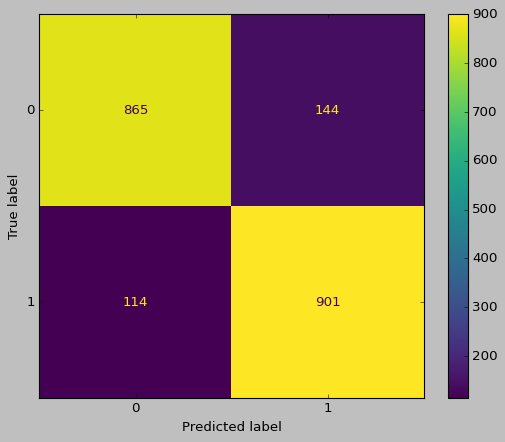

In [ ]:
logreg = LogisticRegression(max_iter=2500,solver = 'lbfgs', penalty = 'l2')
logreg.fit(X_train, y_train)
logreg_predict = logreg.predict(X_test)
logreg_acc = accuracy_score(logreg_predict, y_test)

print("Test accuarcy: {:.2f}%".format(logreg_acc*100))

print('Test performance')
print('-------------------------------------------------------')
print(classification_report(y_test, logreg_predict))

print('Roc_auc score')
print('-------------------------------------------------------')
print(100*roc_auc_score(y_test, logreg_predict))
print('')

print('F1 score')
print('-------------------------------------------------------')
f1_logreg = f1_score(logreg_predict, y_test, average="weighted");
print(f1_logreg)
print('')

print('Confusion Matrix')
style.use('classic')
cm = confusion_matrix(y_test, logreg_predict, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot()

**Random Forest**

Test accuarcy: 86.36%
Test performance
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1009
           1       0.87      0.86      0.86      1015

    accuracy                           0.86      2024
   macro avg       0.86      0.86      0.86      2024
weighted avg       0.86      0.86      0.86      2024

Roc_auc score
-------------------------------------------------------
86.36498117923907

F1 score
-------------------------------------------------------
0.8636376951304598

Confusion Matrix


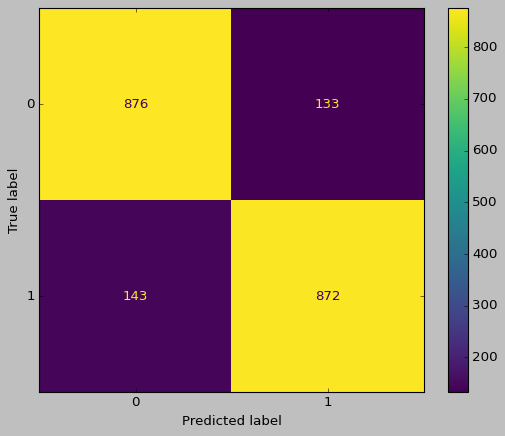

In [ ]:
rf = RandomForestClassifier(n_jobs=-1,n_estimators = 100)
rf.fit(X_train, y_train)
y_train_hat = rf.predict(X_train)
rf_predict = rf.predict(X_test)

rf_acc = accuracy_score(rf_predict, y_test)
print("Test accuarcy: {:.2f}%".format(rf_acc*100))

print('Test performance')
print('-------------------------------------------------------')
print(classification_report(y_test, rf_predict))

print('Roc_auc score')
print('-------------------------------------------------------')
print(100*roc_auc_score(y_test, rf_predict))
print('')

print('F1 score')
print('-------------------------------------------------------')
f1_rf = f1_score(rf_predict, y_test, average="weighted");
print(f1_rf)
print('')

print('Confusion Matrix')
style.use('classic')
cm = confusion_matrix(y_test, rf_predict, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot()

**Naive Bias**

Test accuarcy: 81.32%
Test performance
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1009
           1       0.81      0.82      0.81      1015

    accuracy                           0.81      2024
   macro avg       0.81      0.81      0.81      2024
weighted avg       0.81      0.81      0.81      2024

Roc_auc score
-------------------------------------------------------
81.32248189935896

F1 score
-------------------------------------------------------
0.813248401418738

Confusion Matrix


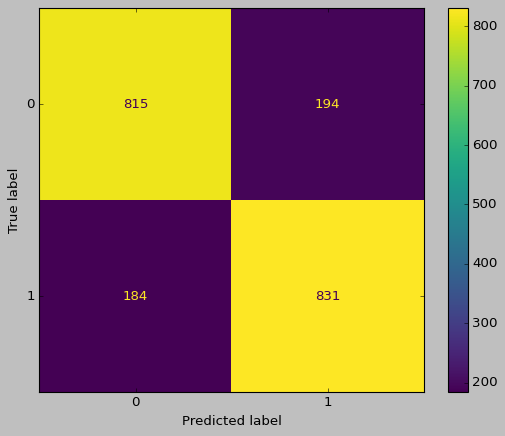

In [ ]:
nb=GaussianNB()
nb.fit(X_train,y_train)
nb_predict = nb.predict(X_test)

nb_acc = accuracy_score(nb_predict, y_test)
print("Test accuarcy: {:.2f}%".format(nb_acc*100))

print('Test performance')
print('-------------------------------------------------------')
print(classification_report(y_test, nb_predict))

print('Roc_auc score')
print('-------------------------------------------------------')
print(100*roc_auc_score(y_test, nb_predict))
print('')

print('F1 score')
print('-------------------------------------------------------')
f1_nb = f1_score(nb_predict, y_test, average="weighted");
print(f1_nb)
print('')

print('Confusion Matrix')
style.use('classic')
cm = confusion_matrix(y_test, nb_predict, labels=nb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
disp.plot()

**Support Vector Machine (SVC)**

Test accuarcy: 87.75%
Test performance
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1009
           1       0.87      0.89      0.88      1015

    accuracy                           0.88      2024
   macro avg       0.88      0.88      0.88      2024
weighted avg       0.88      0.88      0.88      2024

Roc_auc score
-------------------------------------------------------
87.74458445419793

F1 score
-------------------------------------------------------
0.8774808853860236

Confusion Matrix


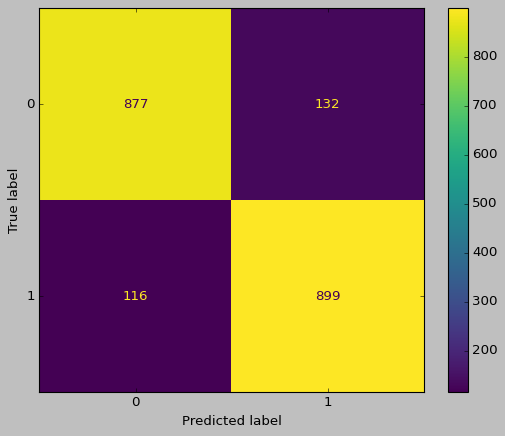

In [ ]:
svm = SVC(kernel='linear')
svm.fit(X_train,y_train)
svm_predict = svm.predict(X_test)
svm_acc=accuracy_score(y_test,svm_predict)

print("Test accuarcy: {:.2f}%".format(svm_acc*100))

print('Test performance')
print('-------------------------------------------------------')
print(classification_report(y_test, svm_predict))

print('Roc_auc score')
print('-------------------------------------------------------')
print(100*roc_auc_score(y_test, svm_predict))
print('')

print('F1 score')
print('-------------------------------------------------------')
f1_svm = f1_score(svm_predict, y_test, average="weighted");
print(f1_svm)
print('')

print('Confusion Matrix')
style.use('classic')
cm = confusion_matrix(y_test, svm_predict, labels=svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot()